### 비선형 SVM 분류

In [15]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# ^ 이 함수가 어떤함수인지 알아보기 ^ 서포트 벡터 머신(SVM)이 학습한 결과를 눈으로 직접 볼 수 있도록 시각화하는 함수
# 1차식 선형모델에만 적용가능
def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0] # 가중치
    b = svm_clf.intercept_[0] # 절편

    # mataplotlib는 x값과 y값이 있어야 그래프를 그릴수있으므로, x값과 y값을 구하기.
    
    # x값 구하기
    x0 = np.linspace(xmin, xmax, 200)

    # y값 구하기
    # svm_clf안에 가중치와 절편을 가져와서 일차방정식을 구한다.
    # 결정 경계에서, w0*x0 + w1*x1 + b = 0
    # => x1 = -w0/w1 * x0 - b/w1
    decision_boundary = -w[0] / w[1] * x0 - b / w[1]

    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    svs = svm_clf.support_vectors_

    plt.plot(x0, decision_boundary, "k-", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_up, "k--", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_down, "k--", linewidth=2, zorder=-2)
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#AAA',
                zorder=-1)

    # 1차식말고 2차식 혹은 3차식의 다항식으로 이루어진 선형모델의 학습결과를 눈으로 볼 수 있도록 시각화 하는 함수 만들어보기

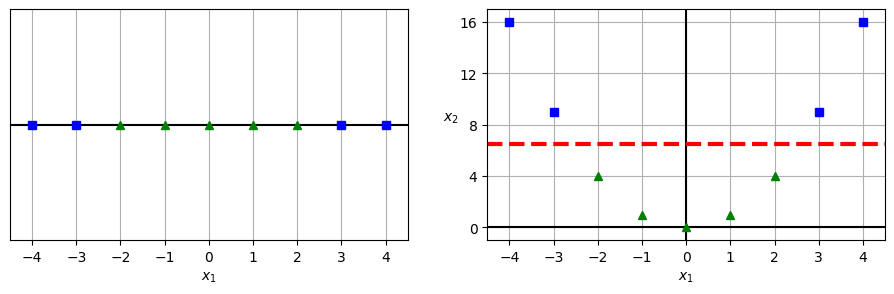

In [ ]:
X1D = np.linspace(-4, 4, 9).reshape(-1, 1)
X2D = np.c_[X1D, X1D**2]
y = np.array([0, 0, 1, 1, 1, 1, 1, 0, 0])

plt.figure(figsize=(10, 3))

plt.subplot(121)
plt.grid(True)
plt.axhline(y=0, color='k')
plt.plot(X1D[:, 0][y==0], np.zeros(4), "bs")
plt.plot(X1D[:, 0][y==1], np.zeros(5), "g^")
plt.gca().get_yaxis().set_ticks([])
plt.xlabel("$x_1$")
plt.axis([-4.5, 4.5, -0.2, 0.2])

plt.subplot(122)
plt.grid(True)
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.plot(X2D[:, 0][y==0], X2D[:, 1][y==0], "bs")
plt.plot(X2D[:, 0][y==1], X2D[:, 1][y==1], "g^")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$  ", rotation=0)
plt.gca().get_yaxis().set_ticks([0, 4, 8, 12, 16])
plt.plot([-4.5, 4.5], [6.5, 6.5], "r--", linewidth=3)
plt.axis([-4.5, 4.5, -1, 17])

plt.subplots_adjust(right=1)


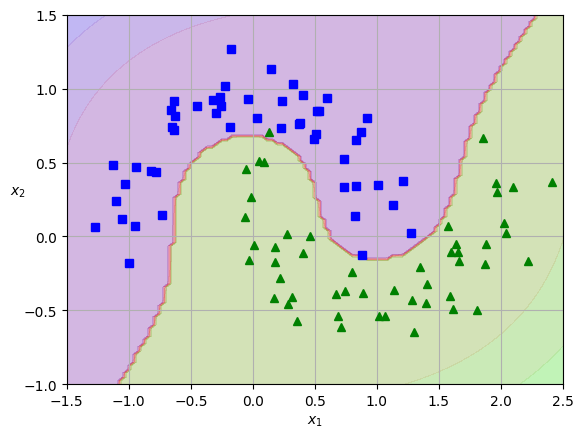

In [18]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LinearSVC(C=10, max_iter=10_000, dual=True, random_state=42)
)
polynomial_svm_clf.fit(X, y)
def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

plot_predictions(polynomial_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])

In [19]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# 데이터 셋 불러오기
iris = datasets.load_iris()

# X, y 지정
X = iris.data[:,[2,3]] # 꽃잎의 길이, 너비
y = (iris.target == 2 ).astype(float) #

# 파이프라인 생성
svm_clf = Pipeline([
    ('scaler',StandardScaler()),
    ('linear_SVC',LinearSVC(random_state=42))
])

# 학습
svm_clf.fit(X,y)

# 예측
print(svm_clf.predict([[5.5,1.7]]))

# C값 변환
svm_clf1 = Pipeline([
    ('scaler',StandardScaler()),
    ('linear_SVC',LinearSVC(C=1,random_state=42))
])
svm_clf2 = Pipeline([
    ('scaler',StandardScaler()),
    ('linear_SVC',LinearSVC(C=100,random_state=42))
])

# 학습
svm_clf1.fit(X,y)
svm_clf2.fit(X,y)

# 예측
print(svm_clf1.predict([[5.5,1.7]]))
print(svm_clf2.predict([[5.5,1.7]]))

[1.]
[1.]
[1.]


[1.]


c:\김지은\파이썬_src\.venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


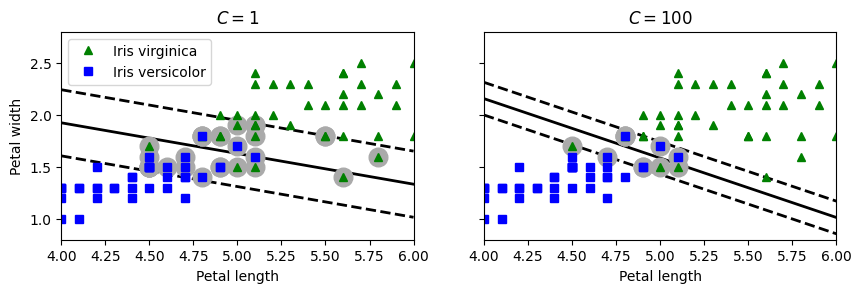

In [20]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt

iris = datasets.load_iris()
X = iris.data[:,[2,3] ]  # 꽃잎의 길이 너비
y = (iris.target == 2).astype(float)

svm_clf =  Pipeline([
    ('scaler',StandardScaler()),
    ('linear_svc',LinearSVC(random_state=42))
])
svm_clf.fit(X,y)

# 예측
print( svm_clf.predict( [[5.5, 1.7]] ) )
scaler = StandardScaler()
svm_clf1 = LinearSVC(C=1, loss="hinge", random_state=42)
svm_clf2 = LinearSVC(C=100, loss="hinge", random_state=42)

scaled_svm_clf1 = Pipeline([
        ("scaler", scaler),
        ("linear_svc", svm_clf1),
    ])
scaled_svm_clf2 = Pipeline([
        ("scaler", scaler),
        ("linear_svc", svm_clf2),
    ])

scaled_svm_clf1.fit(X, y)
scaled_svm_clf2.fit(X, y)

# 스케일되지 않은 파라미터로 변환
b1 = svm_clf1.decision_function([-scaler.mean_ / scaler.scale_])
b2 = svm_clf2.decision_function([-scaler.mean_ / scaler.scale_])
w1 = svm_clf1.coef_[0] / scaler.scale_
w2 = svm_clf2.coef_[0] / scaler.scale_
svm_clf1.intercept_ = np.array([b1])
svm_clf2.intercept_ = np.array([b2])
svm_clf1.coef_ = np.array([w1])
svm_clf2.coef_ = np.array([w2])

# 서포트 벡터 찾기 (그림 표시용)
t = y * 2 - 1
support_vectors_idx1 = (t * (X.dot(w1) + b1) < 1).ravel()
support_vectors_idx2 = (t * (X.dot(w2) + b2) < 1).ravel()
svm_clf1.support_vectors_ = X[support_vectors_idx1]
svm_clf2.support_vectors_ = X[support_vectors_idx2]


# 시각화
fig, axes = plt.subplots(ncols=2, figsize=(10, 2.7), sharey=True)

plt.sca(axes[0])
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^", label="Iris virginica")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs", label="Iris versicolor")
plot_svc_decision_boundary(svm_clf1, 4, 6)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.title("$C = {}$".format(svm_clf1.C))
plt.axis([4, 6, 0.8, 2.8])

plt.sca(axes[1])
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
plot_svc_decision_boundary(svm_clf2, 4, 6)
plt.xlabel("Petal length")
plt.title("$C = {}$".format(svm_clf2.C))
plt.axis([4, 6, 0.8, 2.8])

plt.show()

##### C=1 : 마진이 넓게 만드는 것을 우선시 약간의 오류는 허용
##### C=100 : 마진이 좁아도 좋으니 오류는 허용 안한다. 수치가 클수록 더 엄격하게 오류를 허용 안함

마진이 넓으면 오류를 어느정도 허용 하고 있고, 마진이 좁다면 오류를 엄격하게 허용 안하고 있다고 유추해볼 수 있다.

In [21]:
# 비선형
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
from sklearn.svm import SVC
X,y = make_moons(n_samples=1000, noise=0.15,random_state=42)
ploynomial_svm_clf =  Pipeline([
    ('poly_reatures', PolynomialFeatures(degree=3)),
    ('scaler',StandardScaler()),
    ('svm_clf',LinearSVC(C=100,random_state=42))
])
ploynomial_svm_clf.fit(X,y)

,steps,"[('poly_reatures', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,copy,True
,with_mean,True
,with_std,True


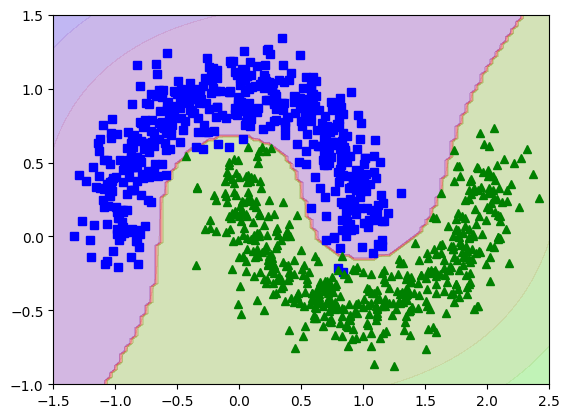

In [22]:
# 시각화
plt.plot(X[:,0][y==0], X[:,1][y==0], 'bs')
plt.plot(X[:,0][y==1], X[:,1][y==1], 'g^')
plot_predictions(polynomial_svm_clf,[-1.5,2.5,-1,1.5])

파이프 라인의 기능에 대하여
Pipeline 안에는 리스트 형태로 튜플 (이름, 변환기/모델) 이 들어갑니다.

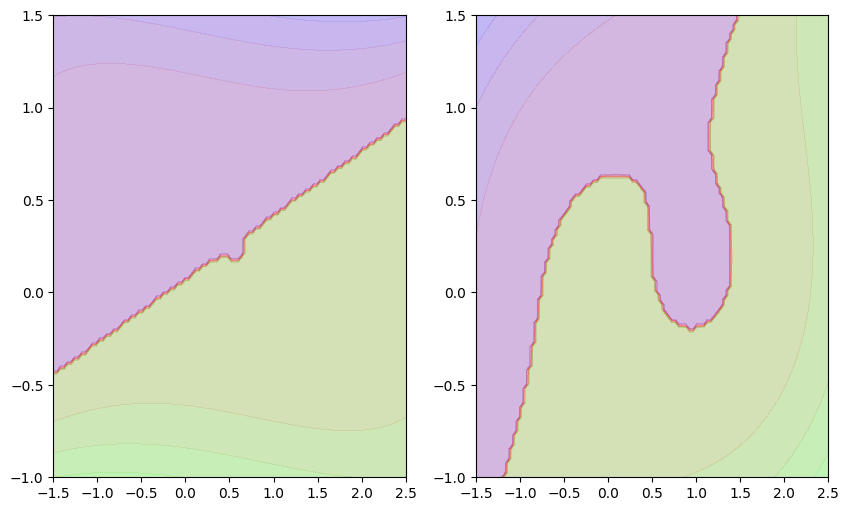

In [ ]:
# ^ 커널 트릭 : 실제로 데이터를 고차원으로 변환하지 않으면서 동일한효과를 발생
from sklearn.svm import SVC
poly_kernal = Pipeline([
    ('scaler',StandardScaler()),
    ('svm_clf',SVC(kernel='poly',degree=3))
])

# 커널트릭
# ('poly_reatures', PolynomialFeatures(degree=3))이걸 생략하고
# ('svm_clf',SVC(kernel='poly',degree=3))로 모델로 대체
# SVM이 내부적으로 다항식 계산 후 결정 경계 학습
# 메모리 효율적, 고차원 데이터도 커널 트릭으로 처리 가능

#완전히 맞는 말만 정리하면 이렇게 됩니다.
# SVC(kernel='poly', degree=3)를 사용하면 SVM이 내부적으로 다항식 커널을 이용해 고차원 특징 공간에서 결정 경계를 학습한다.
# 실제 고차원 벡터를 만들지 않기 때문에 메모리 효율적이다.
# 커널 트릭 덕분에 고차원 데이터도 처리 가능하다.
# ❌ 틀리거나 애매한 부분:
# “PolynomialFeatures(degree=3)를 생략하고 바로 쓰면 똑같은 효과”라고 완전히 단정짓는 것은 정확하지 않음.
# 이유: 다항식 커널은 명시적 변환과 정확히 같은 결과가 아닐 수도 있고, 하이퍼파라미터(coef0, gamma)에 따라 차이가 생김. ^^
# 즉, **핵심은 “커널 트릭으로 고차원 계산을 효율적으로 처리”**라는 점입니다.

poly_kernal.fit(X,y)

poly_kernal_5 = Pipeline([
    ('scaler',StandardScaler()),
    ('svm_clf',SVC(kernel='poly',degree=5,coef0=100,C=5)) # coef0 :  모델이 높은 차수와 낮은 차수에 영향을 받을지 조정
                                                                    # coef0의 값이 크면 고차항의 영향을 더 많이 받는다.
])
poly_kernal_5.fit(X,y)

fig, ax = plt.subplots(1,2,figsize=(10,6))
plt.sca(ax[0])
plot_predictions(poly_kernal,[-1.5,2.5,-1,1.5])
plt.sca(ax[1])
plot_predictions(poly_kernal_5,[-1.5,2.5,-1,1.5])